In [206]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler




In [207]:
import io
import zipfile

import requests
from PIL import Image


def load_images_from_zip(zip_url):
    res = requests.get(zip_url)
    bytes_io = io.BytesIO(res.content)
    images = {'anastasia': [], 'takao': []}

    with zipfile.ZipFile(bytes_io, 'r') as zf:
        for file_name in zf.namelist():
            for key in ['anastasia', 'takao']:
                if file_name.startswith(key) and file_name.endswith('.jpg'):
                    with zf.open(file_name) as f:
                        img = Image.open(f).convert('RGB')
                        images[key].append(img)
    return images

In [208]:
images = load_images_from_zip(
    zip_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/xZQHOyN8ONT92kH-ASb4Pw/data.zip'
    )
type(images)

dict

In [209]:
print(len(images['anastasia']))
print(len(images['takao']))

50
50


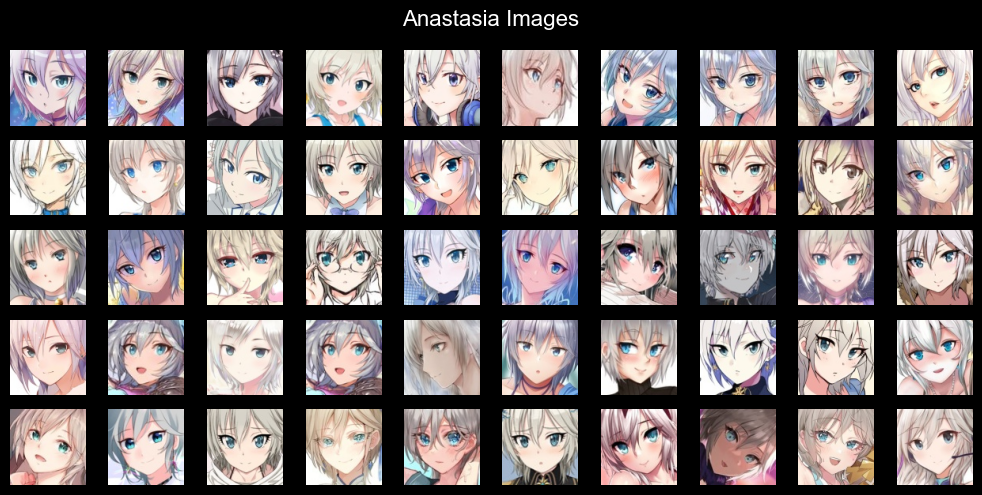

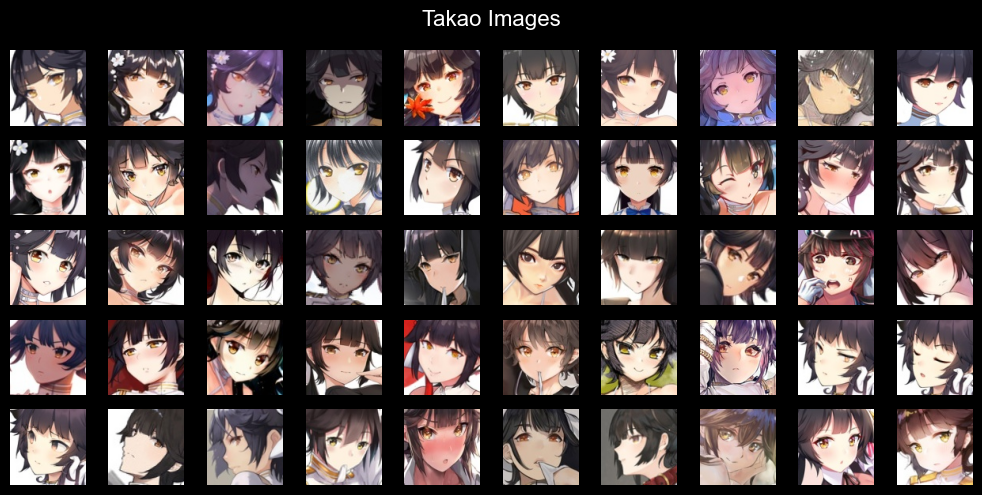

In [210]:
def plot_images(images, title):
    fig, axes = plt.subplots(5, 10, figsize=(10, 5))
    fig.suptitle(title, fontsize=16)
    axes = axes.flatten()
    for img, ax in zip(images, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Plot images from 'anastasia'
plot_images(images['anastasia'], 'Anastasia Images')

# Plot images from 'takao'
plot_images(images['takao'], 'Takao Images')

### 定义数据集

In [211]:
class AnimeDataset(Dataset):
    def __init__(self, images, transform=None):
        self.transform = transform
        self.samples = []
        for label, key in enumerate(images):
            for img in images[key]:
                self.samples.append((img, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, label = self.samples[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


`transforms.ToTensor()` 得到【0，1】的数据

`transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))` 把数据中心移到0，范围对称，得到`[-1,1]`的数据

In [212]:
images

{'anastasia': [<PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,
  <PIL.Image.Image image mode=RGB size=96x96>,


In [213]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = AnimeDataset(images, transform=transform)

### 数据划分

❗工业界不会“直接切 dataset”，而是：

👉 先切 index，再用 Subset 映射回 dataset
```
Dataset        → 定义“有什么数据”
indices        → 生成0-n, 然后对这组自然数2-8划分
Sampler        → 决定“取哪些 index + 顺序”
DataLoader     → 负责“按 batch 取出来”
```

In [214]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

indices = list(range(len(dataset)))

train_i, val_i = train_test_split(indices, test_size=0.2, random_state=seed)

train_sampler = SubsetRandomSampler(train_i)
val_sampler = SubsetRandomSampler(val_i)

train_loader = DataLoader(dataset=dataset, batch_size=8, sampler=train_sampler)
val_loader = DataLoader(dataset=dataset, batch_size=20, sampler=val_sampler)

print(len(train_sampler))
print(len(val_sampler))

80
20


In [215]:
sample_image = dataset[0]
sample_image[0].shape

torch.Size([3, 64, 64])

## Modeling

神经层

```
-> 64*64 图像
conv1 + Relu  ： 32个filter
↓
maxpool1 : 得到32*32特征图
↓
conv2 + relu
↓
maxpool2 ： 得到16*16特征图，64个通道(filters)
↓
fc1 + relu
↓
fc2
```

In [216]:
device = torch.device('mps') if torch.mps.is_available() else torch.device('cpu')

In [217]:
class AnimeCNN(nn.Module):
    def __init__(self):
        super(AnimeCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(in_features=16 * 16 * 64, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        #  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿1﷿﷿﷿﷿﷿﷿﷿﷿﷿
        x = x.view(-1, 64 * 16 * 16)
        x = F.leaky_relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = AnimeCNN().to(device)

In [218]:
model

AnimeCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [219]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training

- model.train() : 🔥 把模型切换到“训练模式（training mode）”
- model.eval(): 把模型切换到评估模式

为什么要计算一个epoch的平均loss 而不是把每个iteration的一批loss.item放成losses？


1. 消除“震荡”，观察真实趋势（降噪）

神经网络的训练过程并不是平滑下降的。

- **Batch Loss 的局限性**：每一个 Batch 的数据都是随机抽样的。如果某个 Batch 里的图片特别难识别，Loss 就会突然飙升；如果下一组图片很简单，Loss 又会骤降。

- **平均值的优势**：如果把每个 Batch 的 Loss 都画出来，曲线会像心电图一样剧烈抖动，很难看出模型是否真的在进步。通过计算一个 Epoch 的平均值，我们**平滑了这种随机波动**，能更清晰地看到模型在整个数据集上的整体收敛趋势。


2. 内存与性能优化

- **内存占用**：如果你训练 100 个 Epoch，每个 Epoch 有 1000 个 Batch，直接保存 `losses` 列表会产生 100,000 个浮点数。虽然这对内存压力不算巨大，但在大规模训练中，记录过细的指标会浪费不必要的存储。

- **绘图压力**：当你在最后使用 `plt.plot(train_losses)` 绘图时，10 万个点的折线图会非常拥挤，甚至导致可视化工具卡顿，而 100 个点的均值曲线则非常直观易读。


3. 指标的对等性（Epoch-wise Comparison）

- 在深度学习中，**Epoch** 是我们衡量训练进度的基本单位。

- 我们通常需要对比“训练集 Loss”和“验证集 Loss”。由于验证集（Validation Set）通常是在一个 Epoch 结束后跑一次完整测试并得到一个平均分，为了公平对比，训练集也应该提供一个**同维度的平均分**。


---



In [220]:
dataset.__getitem__(55)[0].shape

torch.Size([3, 64, 64])

In [221]:
y = model(dataset.__getitem__(8)[0].to(device))
y

tensor([[-0.0403,  0.0432]], device='mps:0', grad_fn=<LinearBackward0>)

In [222]:
num_epochs = 5
train_losses = []
val_losses = []

# ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
print(f"﷿﷿﷿﷿﷿﷿﷿﷿﷿ batch ﷿﷿﷿: {len(train_loader)}")
print(f"﷿﷿﷿﷿﷿﷿﷿﷿﷿ batch ﷿﷿﷿: {len(val_loader)}")

for epoch in range(num_epochs):
    # 进入训练模式
    model.train()
    running_loss = 0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # 进入评估模式
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            loss = criterion(output, labels)
            val_loss += loss.item()

            # ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {100 * correct / total:.2f}%")

﷿﷿﷿﷿﷿﷿﷿﷿﷿ batch ﷿﷿﷿: 10
﷿﷿﷿﷿﷿﷿﷿﷿﷿ batch ﷿﷿﷿: 1
Epoch [1/5] Train Loss: 0.3215 | Val Loss: 0.0013 | Val Acc: 100.00%
Epoch [2/5] Train Loss: 0.0951 | Val Loss: 0.0004 | Val Acc: 100.00%
Epoch [3/5] Train Loss: 0.0102 | Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [4/5] Train Loss: 0.0068 | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [5/5] Train Loss: 0.0019 | Val Loss: 0.0000 | Val Acc: 100.00%


### Evalutation

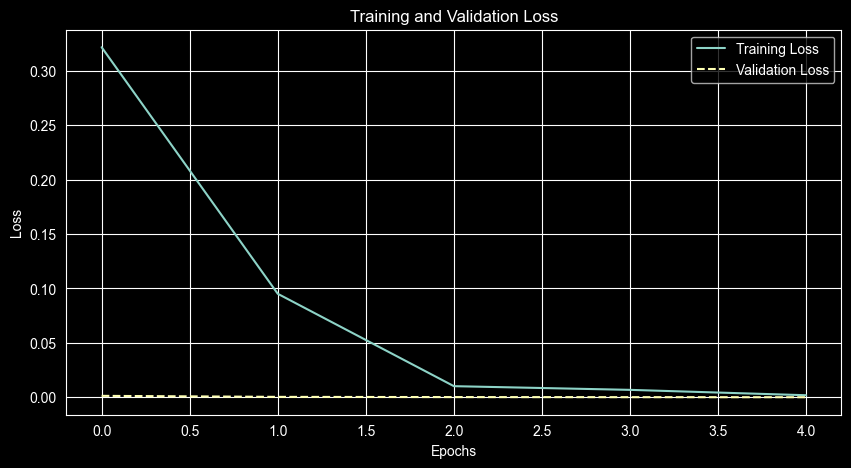

In [223]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training and Validation Loss')
plt.show()

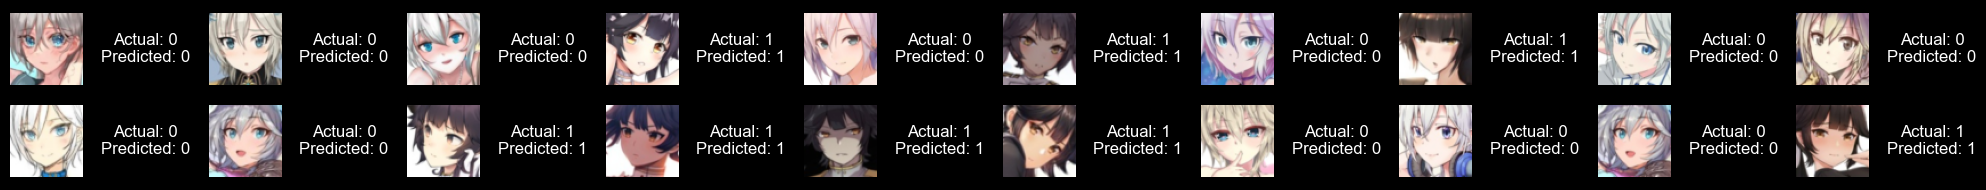

In [224]:
import matplotlib.pyplot as plt
import numpy as np
import torch


# Function to display an image
def imshow(img, ax):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))  # Transpose dimensions to match matplotlib's expected format
    ax.axis('off')


# Set model to evaluation mode
model.eval()

data_iter = iter(val_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Define the grid size
num_images = len(images)
num_cols = 10
num_rows = 2

fig, axs = plt.subplots(num_rows, num_cols * 2, figsize=(20, num_rows))

for idx in range(num_images):
    row = idx // num_cols
    col = (idx % num_cols) * 2

    # Plot the image
    imshow(images[idx].cpu(), axs[row, col])

    # Display actual and predicted labels
    axs[row, col + 1].text(0.5, 0.5, f"Actual: {labels[idx].item()}\nPredicted: {predicted[idx].item()}",
                           horizontalalignment='center', verticalalignment='center', fontsize=12)
    axs[row, col + 1].axis('off')

# Turn off any remaining empty subplots
for idx in range(num_images, num_rows * num_cols):
    row = idx // num_cols
    col = (idx % num_cols) * 2
    axs[row, col].axis('off')
    axs[row, col + 1].axis('off')

plt.tight_layout()
plt.show()

# 练习

0 arcueid_brunestud
1 yukinoshita_yukino


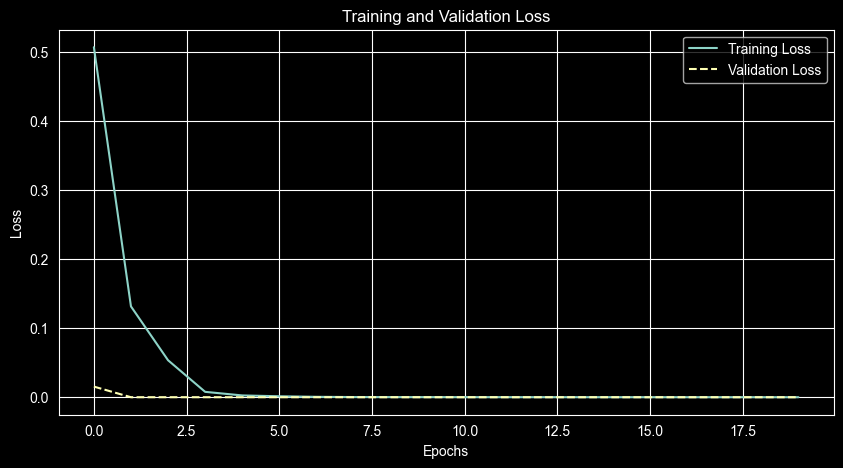

In [229]:
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/yNB99OssvDWOrNTHf2Yuxw/data-practice.zip'


def load_images_from_zip(zip_url):
    res = requests.get(zip_url)
    bytes_io = io.BytesIO(res.content)
    images = {'arcueid_brunestud': [], 'yukinoshita_yukino': []}

    with zipfile.ZipFile(bytes_io, 'r') as zf:
        for file_name in zf.namelist():
            for key in ['arcueid_brunestud', 'yukinoshita_yukino']:
                if file_name.startswith(key) and file_name.endswith('.jpg'):
                    with zf.open(file_name) as f:
                        img = Image.open(f).convert('RGB')
                        images[key].append(img)
    return images


images = load_images_from_zip(zip_file_url)
for a, b in enumerate(images):
    print(a, b)


# Define a new AnimeDataset object for the new dataset.
class AnimeDataset(Dataset):
    def __init__(self, images, transform=None):
        self.transform = transform
        self.samples = []
        for idx_as_lable, key in enumerate(images):
            for img in images[key]:
                self.samples.append((img, idx_as_lable))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, label = self.samples[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = AnimeDataset(images, transform=transform)
# Split the new dataset into training and validation sets.
indices = range(len(images))
t, v = train_test_split(indices, test_size=0.2, random_state=seed)
ts = SubsetRandomSampler(t)
vs = SubsetRandomSampler(v)

# Create DataLoader objects for the new training and validation sets.
tain_loader = DataLoader(dataset, batch_size=8, sampler=ts)
val_loader = DataLoader(dataset, batch_size=8, sampler=vs)

# Define a new CNN model and train it on the new dataset.
class ACNN(nn.Module):
    def __init__(self):
        super(ACNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(16*16*64, 128)
        self.fc2 = nn.Linear(128, 2)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x=torch.flatten(x, 1)
        return self.fc2(F.relu(self.fc1(x)))

model = ACNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20
train_losses = []
val_losses =[]
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for idx, data in enumerate(train_loader, 0):
        inputs , labels =  data
        inputs , labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for idx, data in enumerate(val_loader, 0):
            inputs , labels =  data
            inputs , labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            loss = criterion(output, labels)
            val_loss+=loss.item()
    val_losses.append(val_loss/len(val_loader))

#  Evaluate the new model on the validation set.
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training and Validation Loss')
plt.show()